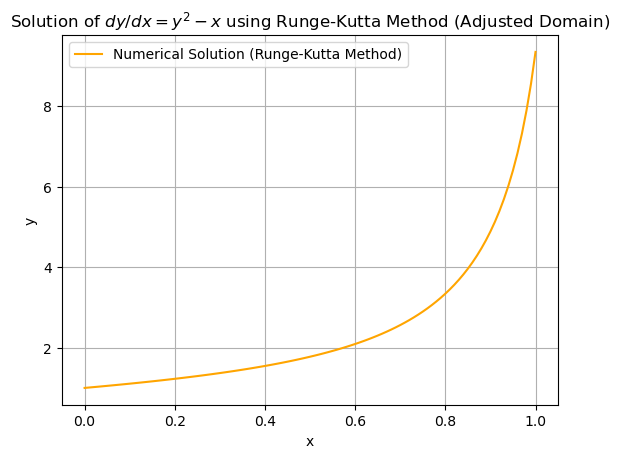

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function representing the ODE dy/dx = y^2 - x
def dydx(x, y):
    return y**2 - x

# Fourth-order Runge-Kutta method for numerical solution of ODE
def runge_kutta_method(dydx, x0, y0, x_end, h):
    x_values = np.arange(x0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0
    
    for i in range(1, len(x_values)):
        x = x_values[i-1]
        y = y_values[i-1]
        
        k1 = h * dydx(x, y)
        k2 = h * dydx(x + h/2, y + k1/2)
        k3 = h * dydx(x + h/2, y + k2/2)
        k4 = h * dydx(x + h, y + k3)
        
        y_values[i] = y + (k1 + 2*k2 + 2*k3 + k4) / 6
    
    return x_values, y_values

# Adjust the domain to avoid large values causing overflow
x0 = 0  # Initial x
y0 = 1  # Initial y
x_end_new = 1  # Limit the domain to avoid instability
h = 0.01  # Step size

# Solve the ODE using Runge-Kutta method with a smaller domain
x_values_rk_new, y_values_rk_new = runge_kutta_method(dydx, x0, y0, x_end_new, h)

# Plot the solution with the new domain
plt.plot(x_values_rk_new, y_values_rk_new, label="Numerical Solution (Runge-Kutta Method)", color="orange")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Solution of $dy/dx = y^2 - x$ using Runge-Kutta Method (Adjusted Domain)")
plt.legend()
plt.grid(True)
plt.show()